(pymc-and-liesel-spike-and-slab)=

# Variable selection with PyMC

Fit a PyMC model with Goose, combining NUTS for continuous parameters with an
exact Gibbs update for binary inclusion indicators. This example uses simulated
data with two active and two inactive predictors. It is independent of the
Liesel-model tutorials; see {doc}`../../goose-engine` for the engine interface.

Use the repository's `pymc` dependency group together with its documentation
dependencies (`uv sync --locked --dev --group pymc`). The example was checked
with Python 3.13, PyMC 6.0.1, PyTensor 3.0.3 and JAX/jaxlib 0.10.1 on CPU with
64-bit mode enabled below. {class}`PyMCInterface <liesel.experimental.pymc.PyMCInterface>` is experimental, so check the example
again when changing that environment. No external dataset is needed.

## Generate observations

There is no intercept; the simulated predictors and errors have zero mean.

Enable 64-bit arithmetic before importing the model interface so PyTensor and
JAX use matching precision. This setting applies to this notebook kernel.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import pandas as pd
import pymc as pm
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
from liesel.experimental.pymc import PyMCInterface

rng = np.random.default_rng(123)
n, p = 500, 4
true_beta = np.array([3.0, 0.0, 4.0, 0.0])

X = rng.normal(size=(n, p)).astype(np.float32)
y = (X @ true_beta + rng.normal(size=n)).astype(np.float32)

## Define the mixture prior

The spike is a narrow **normal distribution**, not a point mass at zero.
Let $s_j$ denote the coefficient prior's standard deviation:

$$
\begin{aligned}
y_i \mid \boldsymbol\beta,\sigma^2
  &\sim \mathcal N(\mathbf x_i^\top\boldsymbol\beta,\sigma^2),\\
\beta_j\mid\delta_j,\tau,\sigma^2
  &\sim \mathcal N(0,s_j^2), &
s_j &= \begin{cases}\nu & \delta_j=0,\\\sqrt{\tau/\sigma^2} & \delta_j=1,\end{cases}\\
\delta_j\mid\theta &\sim \operatorname{Bernoulli}(\theta), &
\theta &\sim \operatorname{Beta}(8,8),\\
\tau &\sim \operatorname{InverseGamma}(1,1), &
\sigma^2 &\sim \operatorname{InverseGamma}(1,1).
\end{aligned}
$$

Here $\nu=0.1$ is fixed and $\tau$ is shared across coefficients. These are the
prior choices of this example: the slab scale depends on the response variance,
and the prior does not enforce that it always exceeds the spike scale.
An indicator of zero favors a small coefficient rather than removing it exactly.
An inclusion probability therefore depends on these prior choices and the
scaling of the predictors.

In [2]:
nu = 0.1

with pm.Model() as spike_and_slab_model:
    # Response variance and mixture hyperparameters.
    sigma2 = pm.InverseGamma("sigma2", alpha=1.0, beta=1.0)
    theta = pm.Beta("theta", alpha=8.0, beta=8.0)
    delta = pm.Bernoulli("delta", p=theta, shape=p)
    tau = pm.InverseGamma("tau", alpha=1.0, beta=1.0)

    # Coefficient mixture and observed response.
    beta = pm.Normal(
        "beta",
        mu=0.0,
        sigma=nu * (1 - delta) + delta * pm.math.sqrt(tau / sigma2),
        shape=p,
    )

    pm.Normal(
        "y",
        mu=X @ beta,
        sigma=pm.math.sqrt(sigma2),
        observed=y,
    )

The model belongs to PyMC, so inspect its native representation here. Liesel's
{meth}`model.plot() <liesel.model.Model.plot>` is for Liesel graphs.

In [3]:
spike_and_slab_model

sigma2 ~ InverseGamma(1, 1)
 theta ~ Beta(8, 8)
 delta ~ Bernoulli(theta)
   tau ~ InverseGamma(1, 1)
  beta ~ Normal(0, f(delta, sigma2, tau))
     y ~ Normal(f(beta), f(sigma2))

## Connect the model

{class}`PyMCInterface <liesel.experimental.pymc.PyMCInterface>` evaluates the model's log density through JAX. Its state uses
PyMC's unconstrained variable names: positive `sigma2` and `tau` become log
variables, and `theta` becomes `theta_logodds__`.

In [4]:
interface = PyMCInterface(spike_and_slab_model)
state = interface.get_initial_state()

In [5]:
pd.DataFrame(
    {
        "State variable": list(state),
        "Shape": [value.shape for value in state.values()],
        "Dtype": [str(value.dtype) for value in state.values()],
    },
)

,State variable,Shape,Dtype
0,sigma2_log__,(),float64
1,theta_logodds__,(),float64
2,delta,"(4,)",int64
3,tau_log__,(),float64
4,beta,"(4,)",float64


The sampler updates these state variables. Below we transform stored draws back
to the original scales for interpretation; this does not change the target.

## Derive the Gibbs update

Conditional on the coefficients and hyperparameters, the indicators are
independent. The likelihood of `y` depends on `beta`, so it cancels when comparing
the two values of an indicator. Writing $\phi(b;0,s)$ for a normal density with
standard deviation $s$, the conditional log odds are

$$
\operatorname{logit}\Pr(\delta_j=1\mid\text{rest})
=\operatorname{logit}(\theta)
 +\log\phi(\beta_j;0,\sqrt{\tau/\sigma^2})
 -\log\phi(\beta_j;0,\nu).
$$

Compute these probabilities from the **current** model state. The logistic
function avoids exponentiating the odds directly. Use the supplied random key
and preserve the shape and integer dtype of the indicator state.

In [6]:
def inclusion_probability(model_state):
    slab_scale = jnp.exp(
        0.5 * (model_state["tau_log__"] - model_state["sigma2_log__"]),
    )
    log_odds = (
        model_state["theta_logodds__"]
        + tfd.Normal(0.0, slab_scale).log_prob(model_state["beta"])
        - tfd.Normal(0.0, nu).log_prob(model_state["beta"])
    )
    return jax.nn.sigmoid(log_odds)


def draw_indicators(prng_key, model_state):
    probability = inclusion_probability(model_state)
    draw = jax.random.bernoulli(prng_key, p=probability)
    return {"delta": draw.astype(model_state["delta"].dtype)}

This is an exact Gibbs update, so no acceptance step or proposal correction is
needed. Exact conditional draws do not guarantee fast mixing of the full chain.
A prior draw `Bernoulli(theta)` would be a different proposal and would need an
MH correction; it is not this conditional distribution.

## Run the sampler

NUTS first updates the continuous block given the current indicators. Gibbs
then updates all indicators given the new continuous values. Jitter disperses
the continuous starting positions and randomly initializes the indicators; each chain has its own random keys.

In [7]:
def jitter(key, value):
    return value + 0.1 * jax.random.normal(key, value.shape)


def jitter_indicators(key, value):
    draw = jax.random.bernoulli(key, p=0.5, shape=value.shape)
    return draw.astype(value.dtype)


continuous = ["beta", "sigma2_log__", "tau_log__", "theta_logodds__"]
builder = gs.EngineBuilder(seed=13, num_chains=4)
builder.set_model(interface)
builder.set_initial_values(state)
builder.set_jitter_fns(
    {**{name: jitter for name in continuous}, "delta": jitter_indicators},
)
builder.add_kernel(gs.NUTSKernel(continuous))
builder.add_kernel(gs.GibbsKernel(["delta"], transition_fn=draw_indicators))

builder.add_adaptation(1000)
builder.add_posterior(1500)
builder.show_progress = False
engine = builder.build()

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


In [8]:
engine.sample_all_epochs()
results = engine.get_results()
samples = results.get_posterior_samples()

liesel.goose.engine - INFO - Finished warmup


## Inspect the fit

Summarize the coefficients and transform the continuous hyperparameters back to
their original scales. All arrays retain the chain and draw axes.

In [9]:
continuous_draws = {
    "beta": samples["beta"],
    "sigma2": jnp.exp(samples["sigma2_log__"]),
    "tau": jnp.exp(samples["tau_log__"]),
    "theta": jax.nn.sigmoid(samples["theta_logodds__"]),
}
continuous_summary = gs.SamplesSummary(continuous_draws)

In [10]:
continuous_summary.to_dataframe().set_index("var_fqn")[
    ["mean", "sd", "mcse_mean", "ess_bulk", "rhat"]
].round(3)

,mean,sd,mcse_mean,ess_bulk,rhat
var_fqn,,,,,
beta[0],2.974,0.043,0.000,7509.981,1.001
beta[1],0.018,0.040,0.000,8789.779,1.000
beta[2],3.922,0.043,0.000,7741.999,1.001
beta[3],0.060,0.040,0.000,8930.206,1.001
sigma2,0.969,0.062,0.001,6173.480,1.000
tau,12.420,24.837,0.456,5469.196,1.002
theta,0.509,0.109,0.001,5914.706,1.000


In [11]:
gs.Summary(results, selected=continuous).error_df().reset_index().filter(
    ["error_msg", "phase", "count"],
)

,error_msg,phase,count
0,divergent transition,warmup,31
1,divergent transition,posterior,0


In this run the response variance is close to its generating value of 1.
All displayed R-hat values are below 1.01 and bulk ESS values exceed 4,900.
The NUTS kernel records warmup divergences but none during posterior sampling.
The shared slab parameter `tau` has a long right tail, reflected in its large
standard deviation.

Use the effective sample sizes and R-hat alongside the errors and traces.
Warmup errors are reported separately from posterior errors; persistent
posterior divergences require investigation before interpreting the draws.

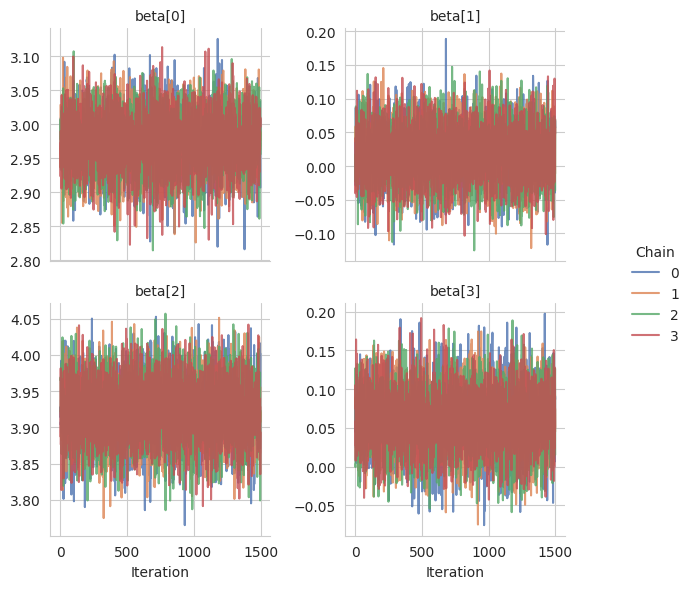

In [12]:
gs.plot_trace(results, params=["beta"], ncol=2)

## Interpret inclusion

The mean of each binary indicator estimates its posterior inclusion probability.
Compare it with the coefficient estimate and the generating value, which is
available here only because the data are simulated.

In [13]:
selection = pd.DataFrame(
    {
        "Generating coefficient": true_beta,
        "Posterior coefficient mean": np.asarray(samples["beta"]).mean(axis=(0, 1)),
        "Inclusion probability": np.asarray(samples["delta"]).mean(axis=(0, 1)),
    },
    index=pd.Index([f"beta[{j}]" for j in range(p)], name="Coefficient"),
)

In [14]:
selection.round(3)

,Generating coefficient,Posterior coefficient mean,Inclusion probability
Coefficient,,,
beta[0],3.0,2.974,1.000
beta[1],0.0,0.018,0.041
beta[2],4.0,3.922,1.000
beta[3],0.0,0.060,0.053


In [15]:
pd.DataFrame(
    np.asarray(samples["delta"]).mean(axis=1),
    columns=[f"delta[{j}]" for j in range(p)],
).rename_axis("Chain").round(3)

,delta[0],delta[1],delta[2],delta[3]
Chain,,,,
0,1.0,0.040,1.0,0.049
1,1.0,0.045,1.0,0.052
2,1.0,0.038,1.0,0.062
3,1.0,0.042,1.0,0.051


The two active predictors have estimated inclusion probabilities near 1,
while the two inactive predictors are around 0.04 and 0.06 in this run.
The per-chain rates agree closely.

An indicator that never switches has undefined R-hat and can have uninformative
ESS; agreement at a constant value is not a convergence check. Inspect the
indicators for the inactive predictors too, alongside the continuous parameters.

To make individual switches visible, show the first 200 posterior iterations
of chain 0. This close-up illustrates indicator movement; use the summaries
above to compare all chains.

In [16]:
indicator_trace = {"delta": samples["delta"][:, :200]}

(results-plot)=

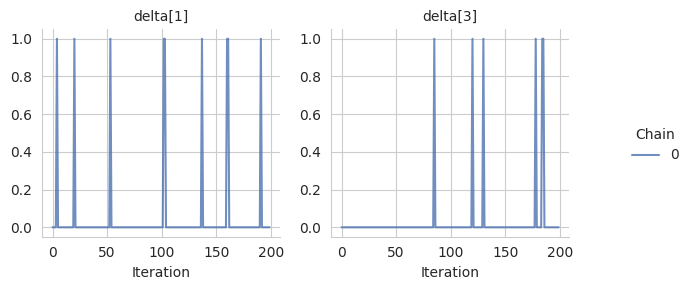

In [17]:
gs.plot_trace(
    indicator_trace,
    params=["delta"],
    param_indices=[1, 3],
    chain_indices=0,
)

The indicators describe membership in the slab component of this prior, not
proof that a scientific effect exists. Correlated predictors, prior scales, and
limited data can make selection uncertain. For diagnostics and model evaluation,
continue with {doc}`../../goose-diagnostics` and
{doc}`../../goose-model-comparison`.